<a href="https://colab.research.google.com/github/Ariel-Pineapple/eda_adidas/blob/main/Caso1_Adidas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FASE 2:** COMPRENSIÓN DE LOS DATOS

**NOMBRE PROYECTO: **MODELO DE ML PARA PREDICCIÓN DE VENTAS

**CLIENTE:** ADIDAS

**CONSULTORA:** MAGIA



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Cargar el dataset (Data Frame)

df = pd.read_csv('Adidas_Sales_Datasets.csv', skiprows=4)
df = df.dropna(axis=1, how='all')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9648 non-null   object
 1   Retailer ID       9648 non-null   int64 
 2   Invoice Date      9648 non-null   object
 3   Region            9648 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Product           9648 non-null   object
 7   Price per Unit    9648 non-null   object
 8   Units Sold        9648 non-null   object
 9   Total Sales       9648 non-null   object
 10  Operating Profit  9648 non-null   object
 11  Operating Margin  9648 non-null   object
 12  Sales Method      9648 non-null   object
dtypes: int64(1), object(12)
memory usage: 980.0+ KB
None


In [9]:
pd.set_option('display.max_columns', None)

In [10]:
#
df.head(5)

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,01/01/20,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","$600,000","$300,000",50%,In-store
1,Foot Locker,1185732,02/01/20,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","$500,000","$150,000",30%,In-store
2,Foot Locker,1185732,03/01/20,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","$400,000","$140,000",35%,In-store
3,Foot Locker,1185732,04/01/20,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$382,500","$133,875",35%,In-store
4,Foot Locker,1185732,05/01/20,Northeast,New York,New York,Men's Apparel,$60.00,900,"$540,000","$162,000",30%,In-store


In [11]:
df.columns

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

In [12]:
print(f"El número de filas es: {df.shape[0]}, el número de columnas es {df.shape[1]}.")

El número de filas es: 9648, el número de columnas es 13.


In [13]:
#
df.describe()



,Retailer ID
count,9.648000e+03
mean,1.173850e+06
std,2.636038e+04
min,1.128299e+06
25%,1.185732e+06
50%,1.185732e+06
75%,1.185732e+06
max,1.197831e+06


In [14]:
df.shape

(9648, 13)

In [15]:
df.describe(include = object)

,Retailer,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
count,9648,9648,9648,9648,9648,9648,9648,9648,9648,9648,9648,9648
unique,6,724,5,50,52,6,94,361,3138,4187,66,3
top,Foot Locker,17/01/21,West,Texas,Portland,Men's Street Footwear,$50.00,225,"$100,000","$63,000",35%,Online
freq,2637,77,2448,432,360,1610,675,207,67,39,1309,4889


In [16]:
df.describe(include = "all")

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
count,9648,9.648000e+03,9648,9648,9648,9648,9648,9648,9648,9648,9648,9648,9648
unique,6,NaN,724,5,50,52,6,94,361,3138,4187,66,3
top,Foot Locker,NaN,17/01/21,West,Texas,Portland,Men's Street Footwear,$50.00,225,"$100,000","$63,000",35%,Online
freq,2637,NaN,77,2448,432,360,1610,675,207,67,39,1309,4889
mean,NaN,1.173850e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.636038e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.128299e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,1.185732e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.185732e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.185732e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df.isnull().sum()

,0
Retailer,0
Retailer ID,0
Invoice Date,0
Region,0
State,0
City,0
Product,0
Price per Unit,0
Units Sold,0
Total Sales,0


Observaciones Generales del Daset

There are 9648 rows and 13 columns in the dataset.

The data type: int64(1), object(12)

The columns in the datasets are:

'Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'

* Las primeras 5 filas eran valores nulos, se eliminaron.

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt

ValueError: could not convert string to float: 'Foot Locker'

<Figure size 1000x600 with 0 Axes>

In [19]:
# Limpiar columnas numéricas

cols_finance = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']
for col in cols_finance:
    df[col] = df[col].str.replace('$', '').str.replace(',', '').astype(float)

# Limpiar margen y fecha

df['Operating Margin'] = df['Operating Margin'].str.replace('%', '').astype(float)
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])




/tmp/ipykernel_391/2414516405.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])


/tmp/ipykernel_391/3666663057.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data = df, x='Region', y='Total Sales', hue='Sales Method', estimator=sum, ci= None)


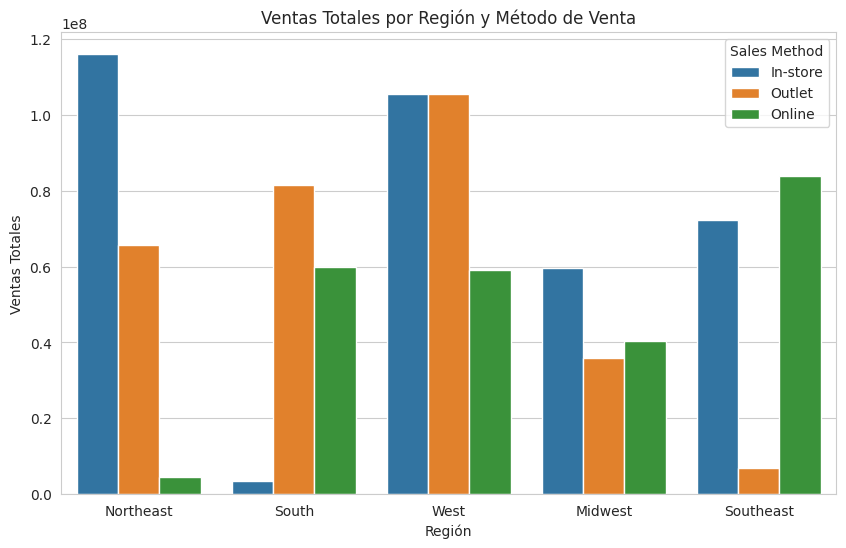

In [21]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(data = df, x='Region', y='Total Sales', hue='Sales Method', estimator=sum, ci= None)
plt.title('Ventas Totales por Región y Método de Venta')
plt.xlabel('Región')
plt.ylabel('Ventas Totales')
plt.show()




/tmp/ipykernel_391/3957832152.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_timeline = df.set_index('Invoice Date').resample('M')['Total Sales'].sum()


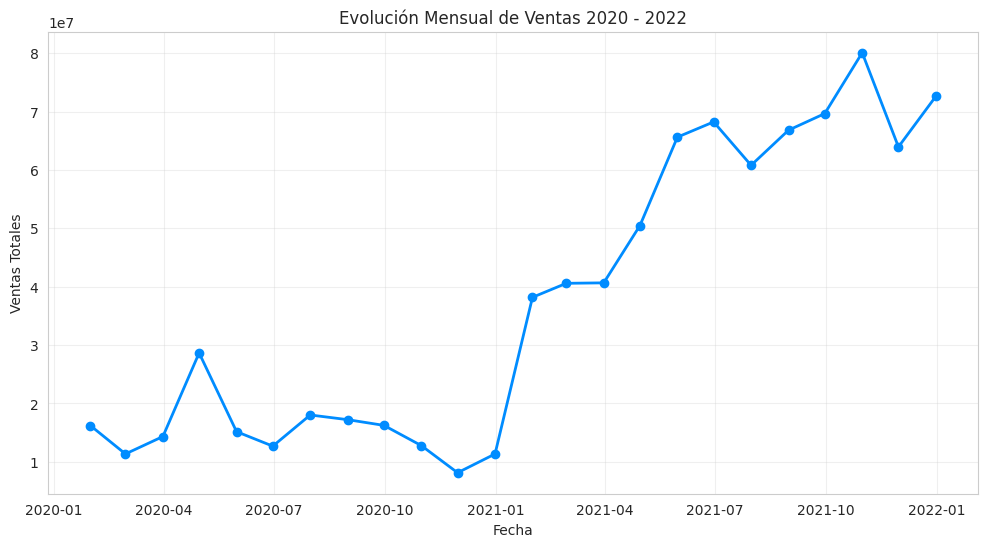

In [23]:
# Gráfico de Tendencias Temporales. Ver como evolucioanron las ventas de Adidas

sales_timeline = df.set_index('Invoice Date').resample('M')['Total Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(sales_timeline.index, sales_timeline.values, marker='o', color='#008CFF', linewidth=2)
plt.title('Tendencia Temporal de Ventas Mensuales')

plt.title('Evolución Mensual de Ventas 2020 - 2022', fontsize=12)
plt.xlabel('Fecha', fontsize=10)
plt.ylabel('Ventas Totales', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

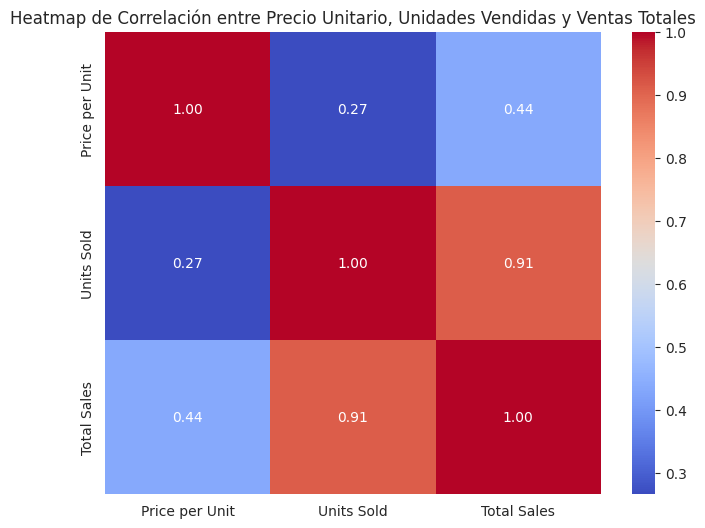

In [24]:
relevant_cols = ['Price per Unit', 'Units Sold', 'Total Sales']
correlation_matrix = df[relevant_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de Correlación entre Precio Unitario, Unidades Vendidas y Ventas Totales')
plt.show()

In [25]:
import plotly.express as px

In [26]:
product_sales = df.groupby('Product')['Total Sales'].sum().reset_index()

fig = px.treemap(product_sales, path=[px.Constant('Productos'), 'Product'], values='Total Sales',
                 title='Dominancia de Productos en el Mercado por Ventas Totales',
                 color_continuous_scale='RdBu')
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()